# Shooting Star — a quantitative teardown
### Daily OHLC · exact-geometry detector · trend split · short-side forward returns · HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calls the top%3F: Busted](https://img.shields.io/badge/Calls_the_top%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect the shooting-star geometry by precise OHLC rules, split by prior trend, trade it short, and test the conditional forward return against each name's own short base rate with a HAC *t*, a label-shuffle placebo, a trend-strength filter, and a synthetic positive control.

> **Not investment advice.** Real data: yfinance daily OHLC (un-adjusted, **price-only** forward returns) for 26 US large-caps + SPY, full history, as-of **2026-06-23**, fingerprint `d488237f4299`. The offline core and the synthetic control are deterministic. Methods & sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from shooting_star import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
HAVE_REAL = data.have_real(cache_dir=CACHE)

def real_panel():
    return data.load_real(cache_dir=CACHE, fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Star short edge **-6.1 bps** at 5d, HAC *t* = **-1.12**; placebo *p* = **0.87**. No horizon clears +2. |
| **Tradability** | `MIRAGE` | Gross edge ≤ 0; the short pays spread **and** borrow. Net at 5d ≈ **-26.1 bps**. No positive break-even cost. |
| **Calls the top?** | `BUSTED` | Pooling all stars, the short edge is **-3.9 bps** at HAC *t* = **-2.15** — *significant, wrong sign*. The wick leans continuation-up. |

> In plain words: the candle's silhouette looks like exhaustion, but the next few days don't agree. On large-caps a long upper wick is closer to a momentum spike than a top.

## 1 · The claim, formalised

For bar $t$ with open $O$, high $H$, low $L$, close $C$:

$$\text{body}=|C-O|,\quad \text{range}=H-L,\quad u=H-\max(O,C),\quad \ell=\min(O,C)-L.$$

The **shooting-star geometry** (steelmanned retail definition):

$$u \ge 2\,\text{body}, \qquad \ell \le 0.5\,\text{body}, \qquad \text{body} \le 0.35\,\text{range},$$

with a small body floor so a doji can't trivially qualify. The folklore assigns the name by **prior trend** ($\operatorname{sgn}(C_t/C_{t-10}-1)>0$ = uptrend = bearish shooting star). The traded claim:

- **H₁ (signal).** $\mathbb{E}[-r_{t+1\to t+1+k}\mid \text{star}] - \text{base}^{\text{short}} > 0$ — shorting the star beats shorting a random day.
- **H₂ (beats placebo).** That edge exceeds the same statistic on random entry days.
- **H₃ (tradable).** It survives one-way costs ×2 **plus short borrow**.

We will fail to reject the null on H₁/H₂ and find H₃ moot — and, pooling the geometry, find a *significant wrong-sign* short return.

## 2 · So what? — what rides on each answer

The shooting star is one of the most-taught single-bar reversal signals. If H₁–H₃ held, it would be a zero-parameter top-timer. The finding that the short edge is *negative and significant* on pooled geometry matters: it says retail traders acting on 'exhaustion' candles are systematically shorting into continuation, paying spread and borrow for the privilege — the same lesson the hammer teardown delivered on the long side.

## 3 · How we'd know — the protocol

- **Detector.** Exact OHLC geometry above; `is_star_shape` (params $2.0 / 0.5 / 0.35$).
- **Trend split.** `trend_at` = sign of the trailing 10-day return at close $t$ (no look-ahead). Star = geometry ∧ uptrend.
- **Timing.** One execution lag: signal at close $t$, enter the short at close $t{+}1$, exit at close $t{+}1{+}k$ for $k\in\{1,3,5,10\}$.
- **Edge.** Conditional short return minus each name's own short base rate (unconditional mean short return at that horizon) — controls for each name's drift.
- **Inference.** Newey–West HAC *t* on the pooled edge (overlapping windows ⇒ i.i.d. *t* would overstate); a per-name label-shuffle placebo (`p = P[shuffled ≥ observed]`).
- **Myth-check.** A trend-strength filter (`min_strength`) keeps only stars after a big run-up — the believer's 'fade only strong rallies' refinement.
- **Positive control.** Synthetic OHLC with a *planted* post-star decline.

Basket: 26 US large-caps + SPY (full yfinance history). **Survivorship** is named on the Signal axis — and for a *bearish* claim it cuts *against* the short (survivors kept rising), so a null short edge is partly mechanical.

## 4 · The teardown

### 4a · Horizon sweep — the short edge and its HAC *t*

If the reversal were real, some horizon's edge should clear *t* = +2.

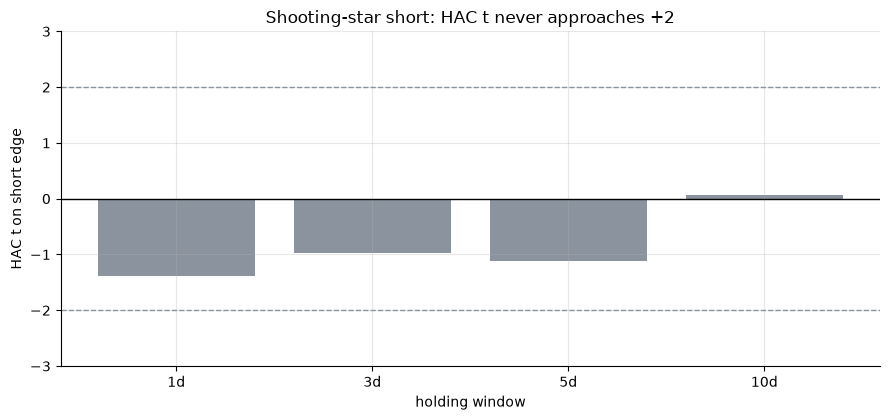

,horizon,n,edge_bps,HAC_t,placebo_p
0,1,5672,-3.1,-1.39,0.889
1,3,5668,-3.9,-0.97,0.816
2,5,5668,-6.1,-1.12,0.870
3,10,5666,0.6,0.07,0.465


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    panel = real_panel()
    res = st.run_experiment(panel, side='star', n_draws=5000)
    edges = [res[h]['edge_mean']*1e4 for h in horizons]
    ts = [res[h]['t'] for h in horizons]
    ps = [res[h]['p_placebo'] for h in horizons]
    ns = [res[h]['n'] for h in horizons]
else:
    edges = [-3.1,-3.9,-6.1,0.6]
    ts = [-1.39,-0.97,-1.12,0.07]
    ps = [0.889,0.816,0.87,0.465]
    ns = [5672,5668,5668,5666]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(h)+'d' for h in horizons], ts, color=[GREEN if t>=2 else GREY for t in ts])
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylim(-3, 3)
ax.set_xlabel('holding window'); ax.set_ylabel('HAC t on short edge')
ax.set_title('Shooting-star short: HAC t never approaches +2')
plt.tight_layout(); plt.show()
tbl = pd.DataFrame({'horizon': horizons, 'n': ns, 'edge_bps': np.round(edges,1),
                    'HAC_t': np.round(ts,2), 'placebo_p': np.round(ps,3)})
tbl

> In plain words: 5,672 uptrend stars, and the short edge sits at noise (-6.1 bps at 5d, *t* -1.12). The placebo *p*-values are all far above 0.05 — random days clear this bar with ease.

### 4b · The pooled geometry — a significant *wrong-sign* short

Drop the trend label and short every star. The bearish story predicts a positive short edge; the tape says the opposite.

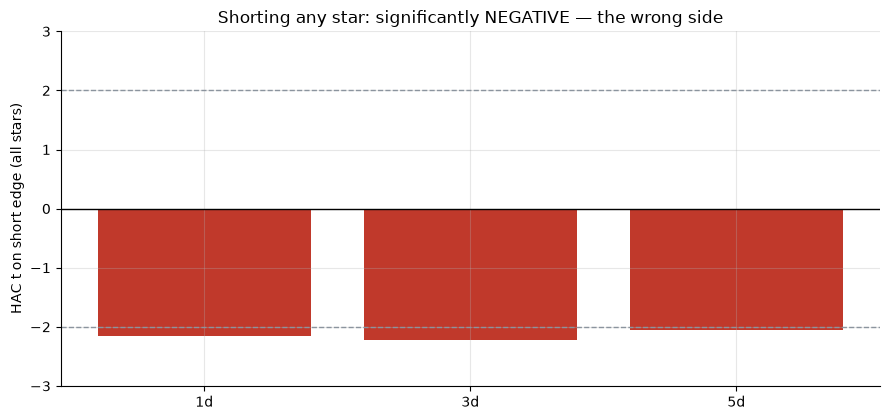

1d: short edge -3.9 bps, HAC t -2.15
3d: short edge -7.0 bps, HAC t -2.23
5d: short edge -8.7 bps, HAC t -2.05


In [3]:
if HAVE_REAL:
    anyr = st.run_experiment(panel, side='any', horizons=[1,3,5], n_draws=5000)
    ae = [anyr[h]['edge_mean']*1e4 for h in [1,3,5]]
    at = [anyr[h]['t'] for h in [1,3,5]]
else:
    ae = [-3.9,-7.0,-8.7]
    at = [-2.15,-2.23,-2.05]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['1d','3d','5d'], at, color=RED)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylim(-3,3)
ax.set_ylabel('HAC t on short edge (all stars)')
ax.set_title('Shorting any star: significantly NEGATIVE — the wrong side')
plt.tight_layout(); plt.show()
for h, e, t in zip([1,3,5], ae, at):
    print(f'{h}d: short edge {e:+.1f} bps, HAC t {t:+.2f}')

> In plain words: at 1/3/5 days the all-star short edge is -3.9 / -7.0 / -8.7 bps with HAC *t* of -2.15 / -2.23 / -2.05. A long upper wick predicts *continuation up* — fading it is a reliable way to be wrong.

### 4c · Per-name breakdown — no name carries the short

26 names. If a true effect existed, several should line up positive. They don't — and the single positive *t* > 2 is exactly what 26 independent draws produce by chance.

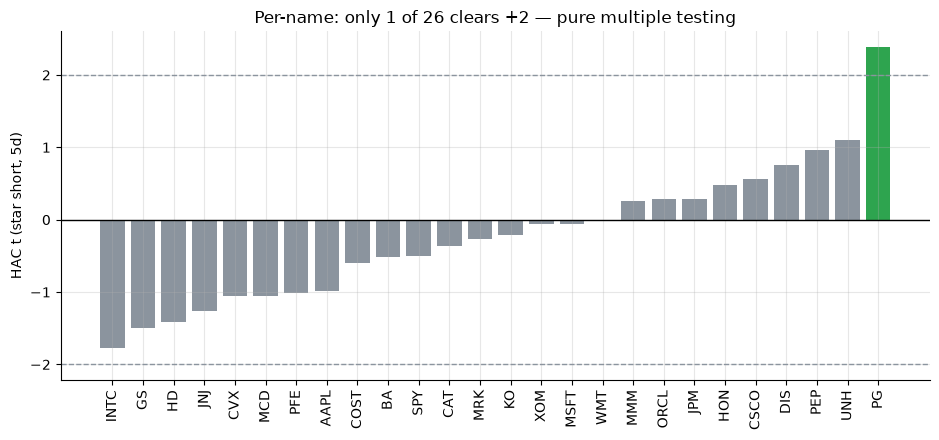

1 of 26 names have HAC t > 2 (chance alone produces ~1 at the 5% level)


In [4]:
if HAVE_REAL:
    recs = []
    for tk, bars in panel.items():
        cr = st.conditional_returns({tk: bars}, 5, side='star')
        recs.append((tk, cr['n'], cr['edge_mean']*1e4, st.hac_t(cr['edge'])))
    per = pd.DataFrame(recs, columns=['ticker','n','edge_bps','t']).sort_values('t')
    npos = int((per['t'] > 2).sum())
else:
    per = pd.DataFrame({'ticker':['GS','...','PG'], 'edge_bps':[-93.1,0,34.1], 't':[-1.50,0,2.38]})
    npos = 1
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(per['ticker'], per['t'], color=[GREEN if t>2 else GREY for t in per['t']])
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); plt.xticks(rotation=90)
ax.set_ylabel('HAC t (star short, 5d)')
ax.set_title(f'Per-name: only {npos} of 26 clears +2 — pure multiple testing')
plt.tight_layout(); plt.show()
print(f'{npos} of 26 names have HAC t > 2 (chance alone produces ~1 at the 5% level)')

> In plain words: one name (PG, *t* = 2.38) is positive-significant out of 26 — the textbook signature of multiple testing, not a real effect. The big movers are *negative* (GS -93 bps).

### 4d · Myth-check — does 'only fade strong rallies' rescue it?

Keep only stars after a large trailing run-up.

In [5]:
strengths = [0.0, 0.05, 0.10, 0.15]
if HAVE_REAL:
    fe, ft, fn = [], [], []
    for ms in strengths:
        cr = st.conditional_returns(panel, 5, side='star', min_strength=ms)
        fe.append(cr['edge_mean']*1e4); ft.append(st.hac_t(cr['edge'])); fn.append(cr['n'])
else:
    fe=[-6.1,3.8,-6.2,0.8]
    ft=[-1.12,0.35,-0.23,0.02]
    fn=[5668,1759,477,143]
tbl = pd.DataFrame({'min_runup': strengths, 'n': fn, 'edge_bps': np.round(fe,1),
                    'HAC_t': np.round(ft,2)})
print(tbl.to_string(index=False))
print('\nThe filter only thins the sample; the edge stays indistinguishable from 0.')

 min_runup    n  edge_bps  HAC_t
      0.00 5668      -6.1  -1.12
      0.05 1759       3.8   0.35
      0.10  477      -6.2  -0.23
      0.15  143       0.8   0.02

The filter only thins the sample; the edge stays indistinguishable from 0.


## 5 · The verdict

- **Signal `NONE`** — star short edge -6.1 bps at 5d, HAC *t* -1.12, placebo *p* 0.87; no horizon, no filter, no name carries a positive short edge past +2 (the one that does is multiple testing).
- **Tradability `MIRAGE`** — gross ≤ 0 and the short pays spread + borrow; net at 5d ≈ -26.1 bps. No positive break-even cost.
- **Calls the top? `BUSTED`** — pooled-geometry short edge -3.9 bps at HAC *t* -2.15 (significant, wrong sign): the long upper wick leans toward continuation up.

## 6 · Could you trade it? — the cost landscape

The star is a short, the most cost-laden side: spread twice plus borrow per day held. Starting below zero, costs only deepen the loss:

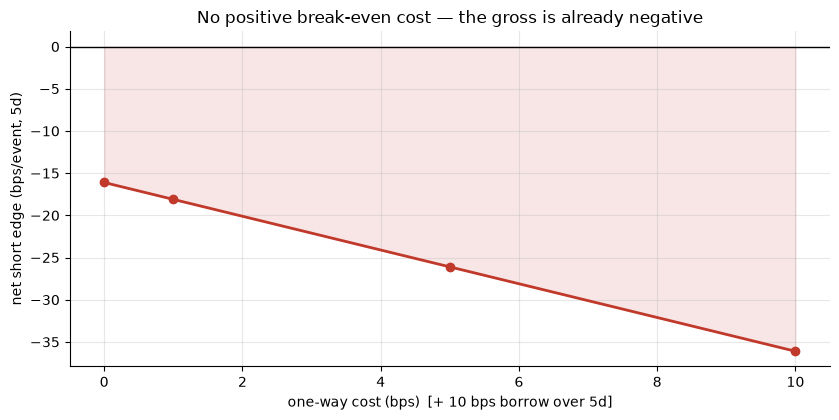

Break-even cost: none — the signal, not the cost, is the problem.


In [6]:
costs = [0.0, 1.0, 5.0, 10.0]
if HAVE_REAL:
    cr = st.conditional_returns(panel, 5, side='star')
    nets = [st.net_of_costs(cr['edge_mean'], cost_bps=c, borrow_bps=2.0*5)*1e4 for c in costs]
else:
    nets = [-16.1, -18.1, -26.1, -36.1]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.fill_between(costs, nets, 0, color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)  [+ 10 bps borrow over 5d]')
ax.set_ylabel('net short edge (bps/event, 5d)')
ax.set_title('No positive break-even cost — the gross is already negative')
plt.tight_layout(); plt.show()
print('Break-even cost: none — the signal, not the cost, is the problem.')

## 7 · Going further — the positive control

Is the engine even capable of finding a post-star decline? Plant one in synthetic OHLC and check the harness recovers it (and stays silent when it's absent):

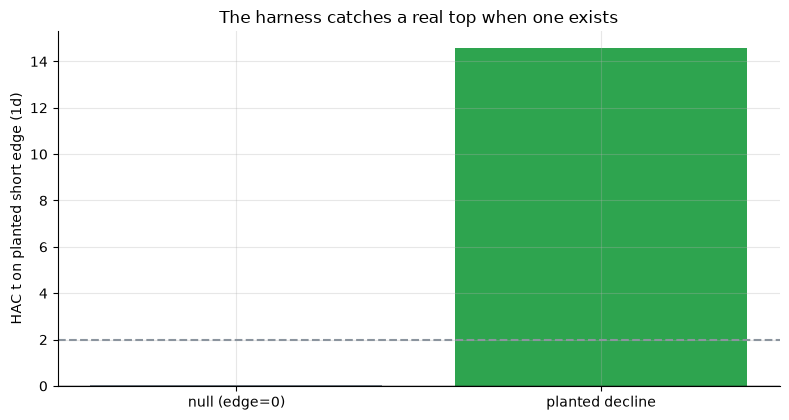

null:    edge +0.1 bps, t +0.03, p 0.492
planted: edge +63.1 bps, t +14.57, p 0.000


In [7]:
p0, _ = data.synthetic_panel(edge=0.0, seed=404)
p1, _ = data.synthetic_panel(edge=0.01, seed=404)
r0 = st.run_experiment(p0, side='star', horizons=[1], n_draws=1000)[1]
r1 = st.run_experiment(p1, side='star', horizons=[1], n_draws=1000)[1]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['null (edge=0)','planted decline'], [r0['t'], r1['t']],
       color=[GREY, GREEN])
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t on planted short edge (1d)')
ax.set_title('The harness catches a real top when one exists')
plt.tight_layout(); plt.show()
print(f"null:    edge {r0['edge_mean']*1e4:+.1f} bps, t {r0['t']:+.2f}, p {r0['p_placebo']:.3f}")
print(f"planted: edge {r1['edge_mean']*1e4:+.1f} bps, t {r1['t']:+.2f}, p {r1['p_placebo']:.3f}")

The engine is a faithful detector: on a planted post-star decline it returns HAC *t* ≈ 15 and placebo *p* = 0; on a pure random walk it sits at *t* ≈ 0.03, *p* ≈ 0.49. The real-tape `NONE` is therefore a statement about the **market** (large-cap upper wicks aren't tops), not the method. Forks worth trying: a confirmation-bar variant, intraday timeframes, or single-name small-caps where reversals may be sharper — show a short edge clearing HAC *t* = +2 that survives the placebo.